--- Memulai Visualisasi Perbandingan ROC ---
Berhasil memuat: ZSC + IndoBERT
Berhasil memuat: ZSC + RoBERTa
Berhasil memuat: InSet + IndoBERT
Berhasil memuat: InSet + RoBERTa


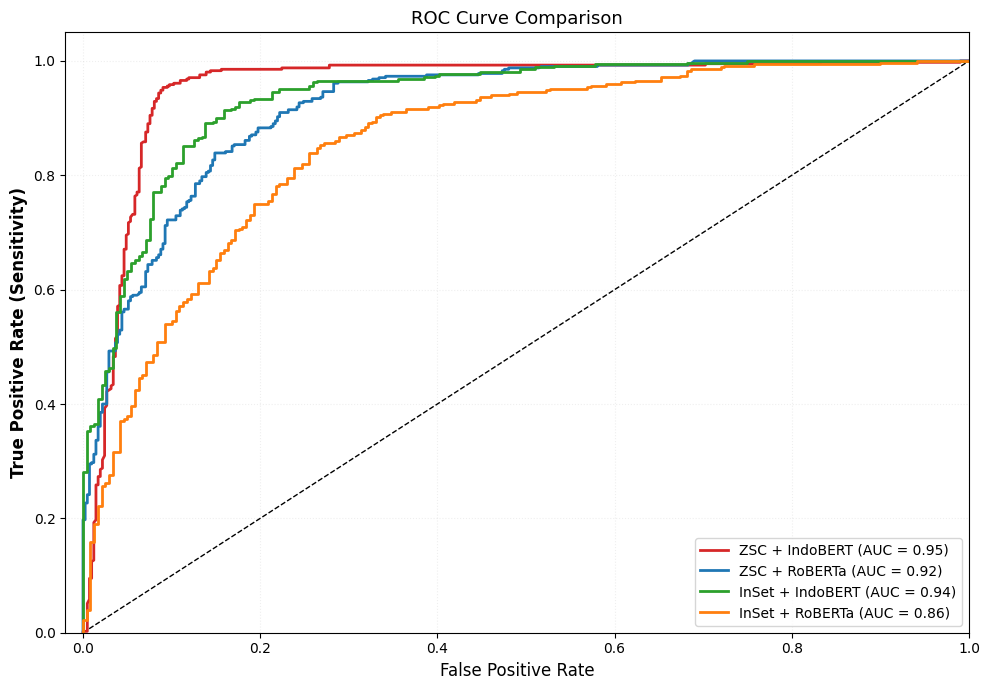


Selesai! Grafik disimpan sebagai 'perbandingan_roc_final_david.png'.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

# 1. Daftar File dan Konfigurasi Visual
# Pastikan nama file di sini SAMA PERSIS dengan yang kamu upload ke Colab
scenarios = [
    {
        'label': 'ZSC + IndoBERT',
        'y_true': 'y_true_zsc_indobert.npy',
        'y_score': 'y_score_zsc_indobert.npy',
        'color': '#d62728', # Merah
        'linestyle': '-'
    },
    {
        'label': 'ZSC + RoBERTa',
        'y_true': 'y_true_zsc_roberta.npy',
        'y_score': 'y_score_zsc_roberta.npy',
        'color': '#1f77b4', # Biru
        'linestyle': '-'
    },
    {
        'label': 'InSet + IndoBERT',
        'y_true': 'y_true_inset_indobert.npy',
        'y_score': 'y_score_inset_indobert.npy',
        'color': '#2ca02c', # Hijau
        'linestyle': '-'
    },
    {
        'label': 'InSet + RoBERTa',
        'y_true': 'y_true_inset_roberta.npy',
        'y_score': 'y_score_inset_roberta.npy',
        'color': '#ff7f0e', # Oranye
        'linestyle': '-'
    }
]

# 2. Inisialisasi Plot
plt.figure(figsize=(10, 7))

# Tambahkan garis diagonal referensi (Random Guess)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')

# 3. Proses Penggabungan
print("--- Memulai Visualisasi Perbandingan ROC ---")
for sc in scenarios:
    if os.path.exists(sc['y_true']) and os.path.exists(sc['y_score']):
        # Load Data
        y_true = np.load(sc['y_true'])
        y_score = np.load(sc['y_score'])

        # Hitung ROC & AUC
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        # Plotting
        plt.plot(
            fpr, tpr,
            color=sc['color'],
            linestyle=sc['linestyle'],
            lw=3 if 'Best' in sc['label'] else 2,
            label=f"{sc['label']} (AUC = {roc_auc:.2f})"
        )
        print(f"Berhasil memuat: {sc['label']}")
    else:
        print(f"Gagal memuat: {sc['label']} (File tidak ditemukan di folder /content/)")

# 4. Atur Estetika (Styling Skripsi)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison', fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.2, linestyle=':')

# 5. Simpan Hasil
plt.tight_layout()
nama_hasil = 'perbandingan_roc_final_david.png'
plt.savefig(nama_hasil, dpi=300) # Resolusi 300 DPI untuk cetak skripsi
plt.show()

print(f"\nSelesai! Grafik disimpan sebagai '{nama_hasil}'.")

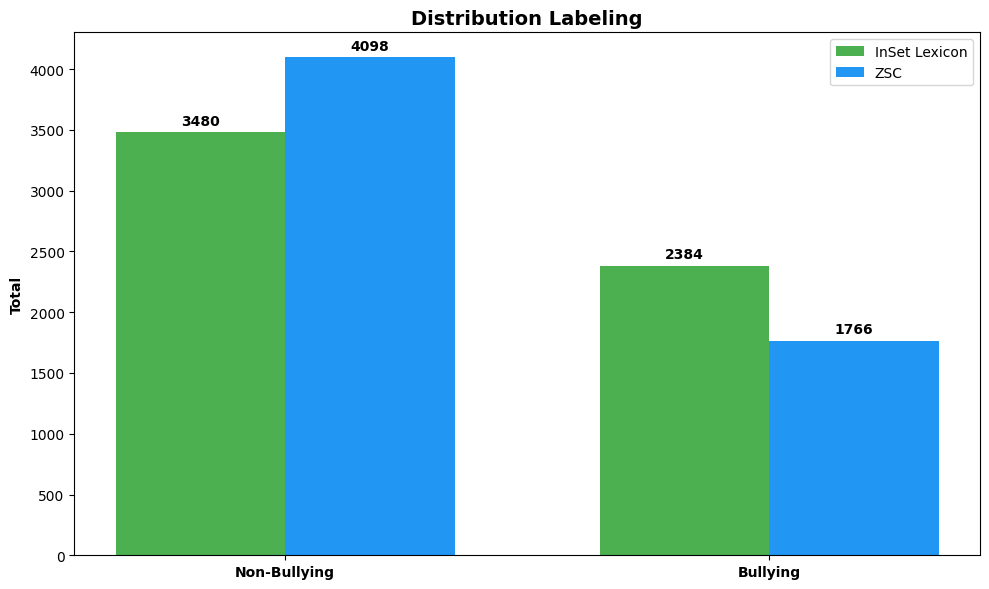

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['Non-Bullying', 'Bullying']
inset_data = [3480, 2384]
zsc_data = [4098, 1766]

x = np.arange(len(labels))  # Lokasi label
width = 0.35  # Lebar batang

fig, ax = plt.subplots(figsize=(10, 6))

# Membuat batang berdampingan
rects1 = ax.bar(x - width/2, inset_data, width, label='InSet Lexicon', color='#4CAF50')
rects2 = ax.bar(x + width/2, zsc_data, width, label='ZSC', color='#2196F3')

# Tambahkan teks dan label
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Distribution Labeling', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend()

# Fungsi untuk memberi label angka di atas setiap batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('bar_labeling_final.png', dpi=300)
plt.show()

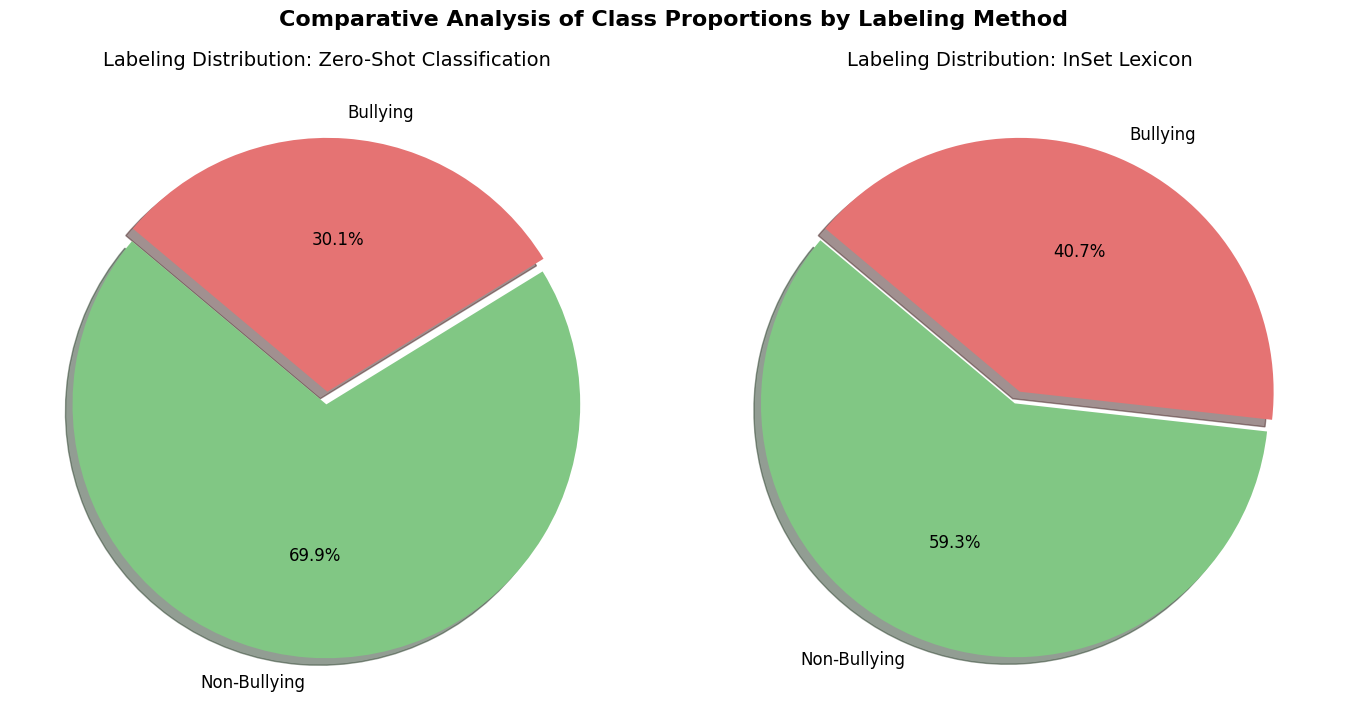

Visualization complete! The file 'labeling_distribution_comparison_en.png' is ready for download.


In [ ]:
import matplotlib.pyplot as plt

# Data based on labeling results:
# ZSC: Non-Bullying (4,098), Bullying (1,766)
zsc_data = [4098, 1766]
# InSet: Non-Bullying (3,480), Bullying (2,384)
inset_data = [3480, 2384]

labels = ['Non-Bullying', 'Bullying']
colors = ['#81C784', '#E57373'] # Soft Green & Soft Red

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Pie Chart 1: Zero-Shot Classification (ZSC) Distribution
ax1.pie(zsc_data, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0.05, 0), shadow=True, textprops={'fontsize': 12})
ax1.set_title('Labeling Distribution: Zero-Shot Classification', fontsize=14)

# Pie Chart 2: InSet Lexicon Distribution
ax2.pie(inset_data, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0.05, 0), shadow=True, textprops={'fontsize': 12})
ax2.set_title('Labeling Distribution: InSet Lexicon', fontsize=14)

# Main Title
plt.suptitle('Comparative Analysis of Class Proportions by Labeling Method',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
# Save high-resolution image for your thesis
plt.savefig('labeling_distribution_comparison_en.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization complete! The file 'labeling_distribution_comparison_en.png' is ready for download.")

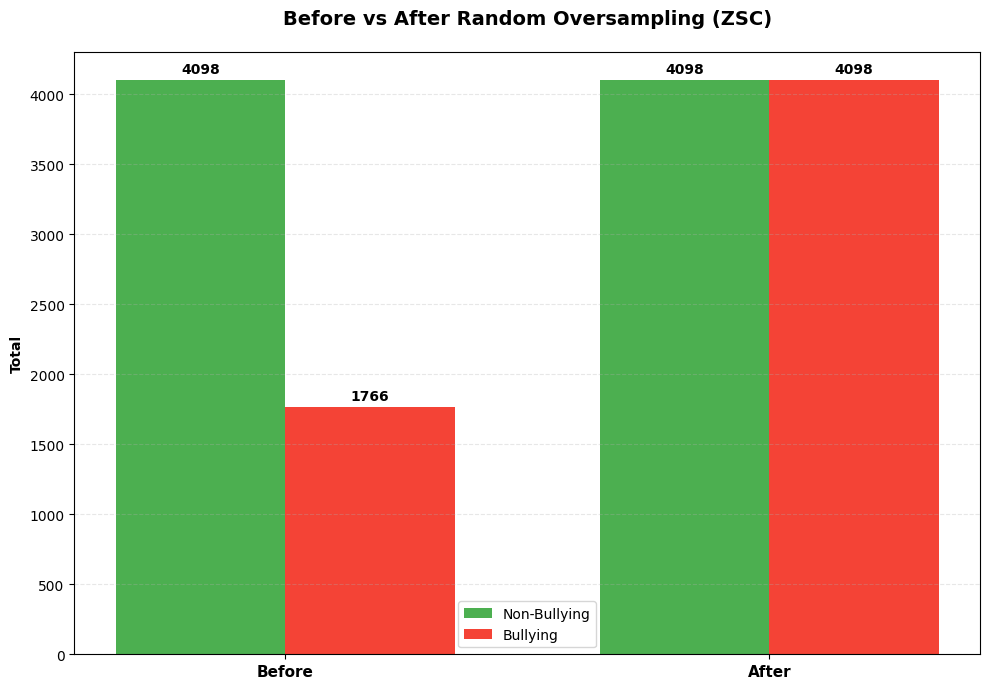

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data dikelompokkan berdasarkan Tahapan
groups = ['Before', 'After']
non_bullying = [4098, 4098] # Jumlah Non-Bullying tetap
bullying = [1766, 4098]     # Jumlah Bullying berubah (naik)

x = np.arange(len(groups))  # Lokasi kelompok (0 untuk Sebelum, 1 untuk Sesudah)
width = 0.35  # Lebar batang

fig, ax = plt.subplots(figsize=(10, 7))

# Plot batang: Non-Bullying dan Bullying dikelompokkan di bawah 'Sebelum' dan 'Sesudah'
rects1 = ax.bar(x - width/2, non_bullying, width, label='Non-Bullying', color='#4CAF50')
rects2 = ax.bar(x + width/2, bullying, width, label='Bullying', color='#F44336')

# Tambahkan detail teks
ax.set_ylabel('Total', fontweight='bold')
ax.set_title('Before vs After Random Oversampling (ZSC)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontweight='bold', fontsize=11)
ax.legend()

# Fungsi untuk memberi label angka di atas setiap batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('oversampling_by_stage.png', dpi=300)
plt.show()

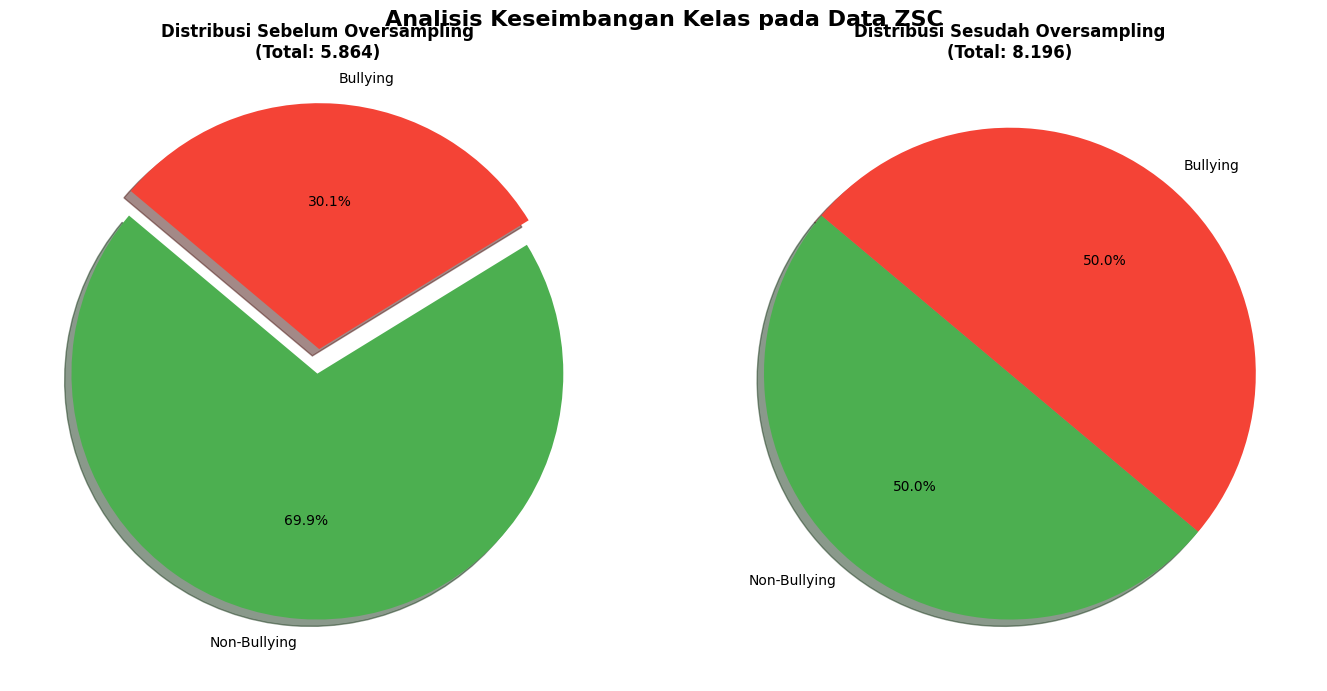

In [ ]:
# Data Pie
colors = ['#4CAF50', '#F44336'] # Hijau & Merah
labels = ['Non-Bullying', 'Bullying']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Sebelum
ax1.pie(before_oversampling, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0.1), shadow=True)
ax1.set_title('Distribusi Sebelum Oversampling\n(Total: 5.864)', fontsize=12, fontweight='bold')

# Sesudah
ax2.pie(after_oversampling, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True)
ax2.set_title('Distribusi Sesudah Oversampling\n(Total: 8.196)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis Keseimbangan Kelas pada Data ZSC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_oversampling_final.png', dpi=300)
plt.show()